# Monte Carlo Scenario Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [2]:
# plotting settings
primary_color = '#00246B'
secondary_color = '#CADCFC'

# global style
sns.set_style("whitegrid")
plt.rcParams['figure.autolayout'] = True
custom_palette = sns.blend_palette([primary_color, secondary_color], n_colors=5)
sns.set_palette(custom_palette)
line_styles = ['-', '--', '-.', ':', '-']

In [3]:
# load the scenarios generated by main.py
file_path = '../output/scenarios.csv'
df = pd.read_csv(file_path)
print(df.head())
print(np.shape(df))

   Scenario  Step         1         2         3         4         5
0         1     1 -0.006541 -0.000939  0.052539 -0.009811 -0.004513
1         1     2  0.018740 -0.003672 -0.002224  0.028108  0.006978
2         1     3  0.007916 -0.018233  0.003791  0.011873 -0.002505
3         1     4  0.001673  0.004117  0.046028  0.002509  0.001006
4         1     5 -0.081534  0.003709  0.137430 -0.122272 -0.037907
(120000, 7)


## Analysis and Visualization of Scenario Data

In [4]:
# group by scenario and sum Log Returns
assets = [col for col in df.columns if col not in ['Scenario', 'Step']]

# R_cum = exp(sum(r_t)) - 1
scenario_returns = df.groupby('Scenario')[assets].apply(lambda x: np.exp(x.sum()) - 1)
headers = ["HighGrowth", "Bond", "Gold", "1.5xHighGrowth", "LowGrowth"]
scenario_returns.columns = headers
scenario_returns.head()

,HighGrowth,Bond,Gold,1.5xHighGrowth,LowGrowth
Scenario,,,,,
1,-0.011417,0.000232,0.307789,-0.017063,-0.011460
2,0.169581,0.087598,0.057593,0.264757,0.108243
3,0.061165,-0.050261,-0.079002,0.093114,0.000926
4,0.052965,0.037529,0.126495,0.080482,0.044367
5,0.091718,0.029379,0.107059,0.140661,0.066092


In [5]:
summary_stats = scenario_returns.describe().T
summary_stats

,count,mean,std,min,25%,50%,75%,max
HighGrowth,10000.0,0.009143,0.121762,-0.833426,-0.063271,0.001113,0.071551,1.208180
Bond,10000.0,0.000211,0.042822,-0.218905,-0.027362,-0.000908,0.026928,0.252416
Gold,10000.0,0.014320,0.165240,-0.537017,-0.097315,-0.000243,0.111017,1.212207
1.5xHighGrowth,10000.0,0.019219,0.187563,-0.931936,-0.093377,0.001667,0.109206,2.279851
LowGrowth,10000.0,0.002711,0.062904,-0.543469,-0.033955,0.000237,0.037559,0.586347


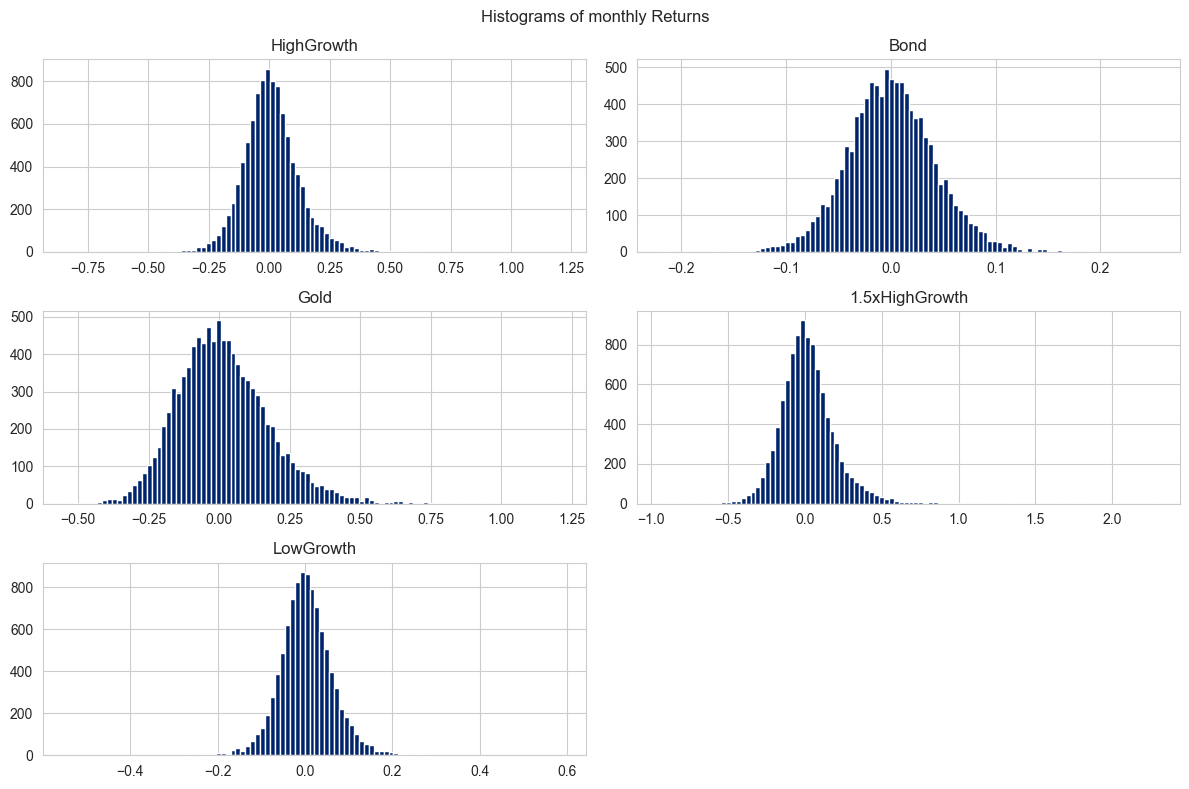

In [6]:
# plot histograms
scenario_returns.hist(bins=100, figsize=(12, 8))
plt.suptitle('Histograms of monthly Returns')
plt.show()

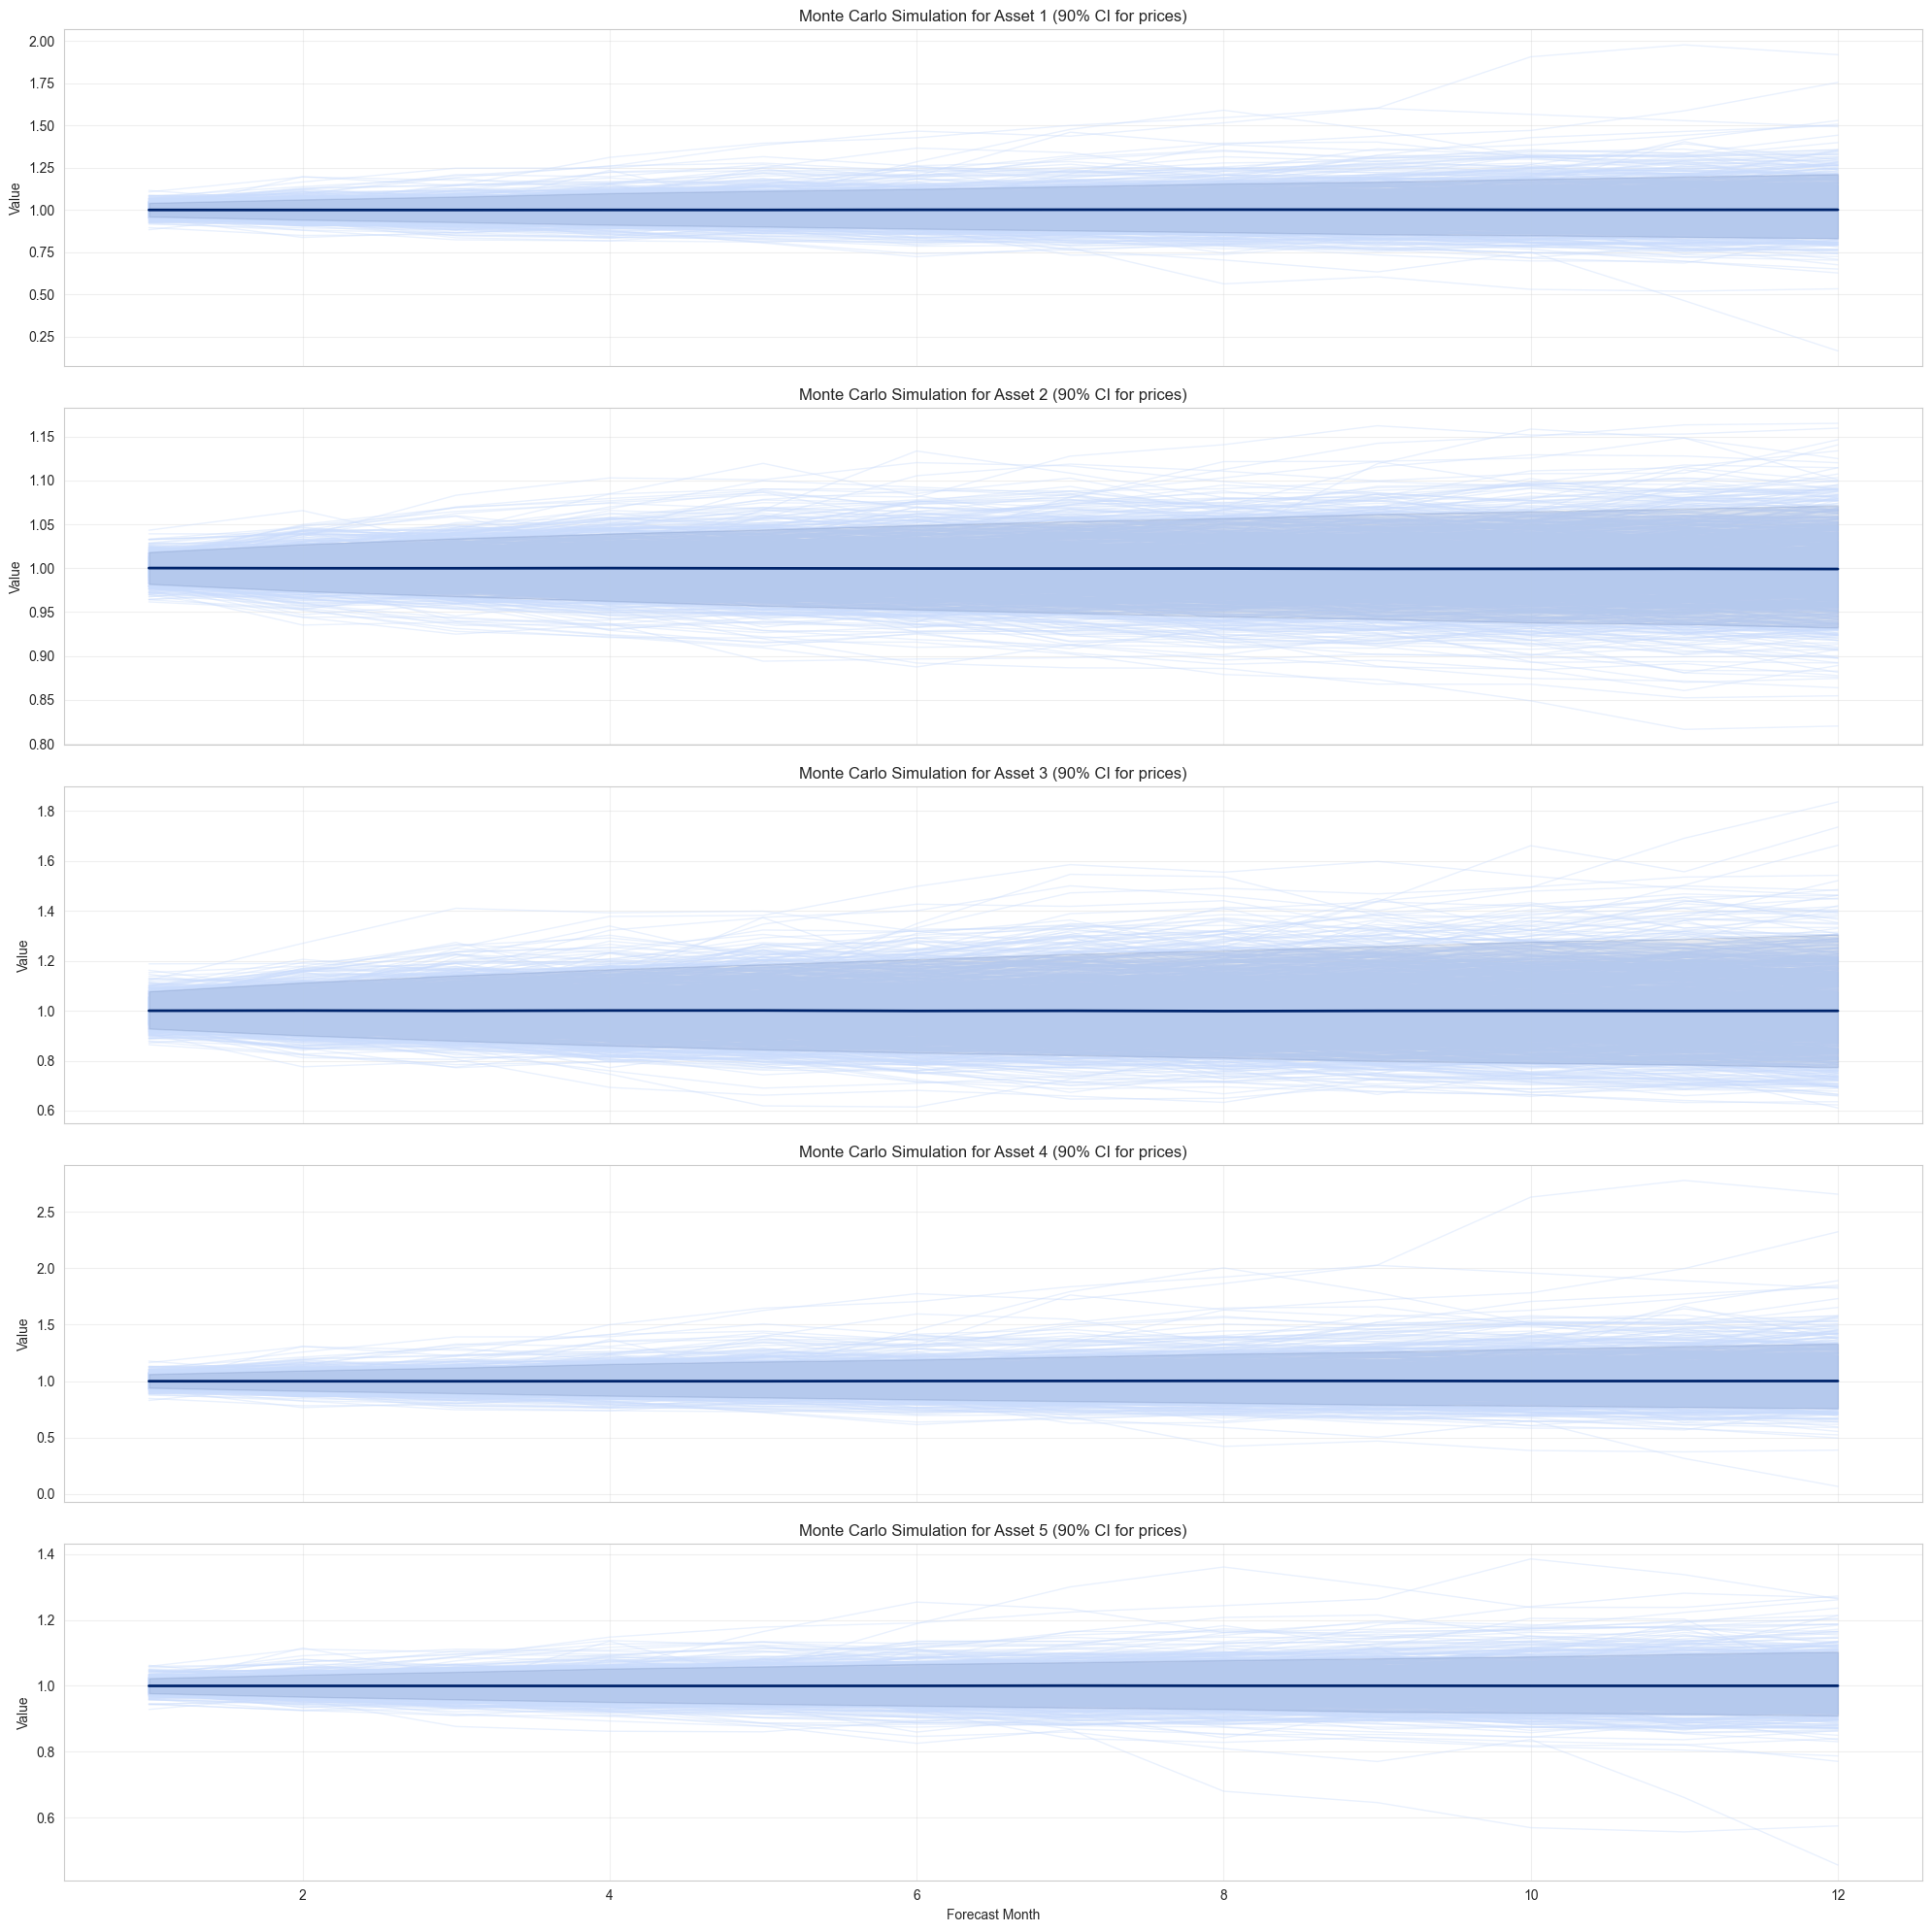

In [7]:
# visualization of the simulation paths for the price level
assets = [col for col in df.columns if col not in ['Scenario', 'Step']]

# convert returns to price index (Base 1)
fig, axes = plt.subplots(len(assets), 1, figsize=(20,20), sharex=True)
for i, asset in enumerate(assets):
    # get paths for the asset
    asset_returns = df.pivot(index='Step', columns='Scenario', values=asset)
    price_paths = np.exp(asset_returns.cumsum())
    steps = price_paths.index
    
    # stats for visualization
    p10 = price_paths.quantile(0.05, axis=1) 
    p50 = price_paths.quantile(0.50, axis=1)
    p90 = price_paths.quantile(0.95, axis=1) 
    
    ax = axes[i]
    # plot paths
    sample_paths = price_paths.sample(n=1000, axis=1, random_state=42)
    ax.plot(steps, sample_paths, color=secondary_color, alpha=0.4, linewidth=1, zorder=1)
    # 90% confidence interval
    ax.fill_between(steps, p10, p90, color=primary_color, alpha=0.1, label='90% CI')
    # median
    ax.plot(steps, p50, color=primary_color, linewidth=2, label='Median Projection')
    ax.set_title(f'Monte Carlo Simulation for Asset {asset} (90% CI for prices)')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)

plt.xlabel('Forecast Month')
plt.tight_layout()
plt.show()

### Tail Risk Measures

In [8]:
# VaR and CVaRat 95% confidence
def var_and_cvar(x, alpha=0.05):
    # VaR: threshold where 5% of outcomes are worse
    var = x.quantile(alpha)
    # CVaR: average loss of those worst 5% outcomes
    cvar = x[x <= var].mean()
    return pd.Series({'VaR 95%': var, 'CVaR 95%': cvar})

extended_stats = pd.concat([
    scenario_returns.describe(),
    scenario_returns.apply(var_and_cvar)
])

extended_stats_T = extended_stats.T
extended_stats_T

,count,mean,std,min,25%,50%,75%,max,VaR 95%,CVaR 95%
HighGrowth,10000.0,0.009143,0.121762,-0.833426,-0.063271,0.001113,0.071551,1.208180,-0.167689,-0.230241
Bond,10000.0,0.000211,0.042822,-0.218905,-0.027362,-0.000908,0.026928,0.252416,-0.067664,-0.088477
Gold,10000.0,0.014320,0.165240,-0.537017,-0.097315,-0.000243,0.111017,1.212207,-0.226432,-0.282587
1.5xHighGrowth,10000.0,0.019219,0.187563,-0.931936,-0.093377,0.001667,0.109206,2.279851,-0.240628,-0.322287
LowGrowth,10000.0,0.002711,0.062904,-0.543469,-0.033955,0.000237,0.037559,0.586347,-0.090182,-0.129175


**Observations (Horizon Risk Metrics):**
- **Terminal Risk Interpretation:** Since we simulate a 1-year horizon, these metrics represent the *final* outcome risk. A VaR of -15% means there is a 5% chance the asset value is down >15% at year-end.
- **Value at Risk (VaR 95%):** The "cutoff" for the worst 5% of scenarios. Asset 4 shows significantly deeper VaR, confirming its high leverage risk.
- **Expected Shortfall (CVaR):** This is the *average* loss when the 5% worst-case actually happens. The large gap between VaR and CVaR for the equity-like assets indicates "fat tails"—when things go wrong, they tend to go *very* wrong.

In [9]:
# Skewness, Kurtosis, and Probability of Crash
def tail_risk_probabilities(x):
    return pd.Series({
        'Skewness': x.skew(),
        'Excess Kurtosis': x.kurtosis(),
        'Prob(Return < -15%)': (x < -0.15).mean(),
        'Prob(Return < -30%)': (x < -0.30).mean(),
        'Prob(Return < -50%)': (x < -0.50).mean()

    })

tail_stats = scenario_returns.apply(tail_risk_probabilities).T
tail_stats

,Skewness,Excess Kurtosis,Prob(Return < -15%),Prob(Return < -30%),Prob(Return < -50%)
HighGrowth,0.804878,5.037248,0.0687,0.0056,0.0004
Bond,0.163727,0.957909,0.0006,0.0000,0.0000
Gold,0.679543,1.519185,0.1488,0.0144,0.0002
1.5xHighGrowth,1.370219,8.303600,0.1443,0.0224,0.0024
LowGrowth,0.400074,5.347833,0.0109,0.0006,0.0001


**Observations:**
- **Extreme Fat Tails (Kurtosis):** Asset 4 (Kurtosis > 135) and Asset 1 show extreme fat tails $\to$ massive outlier events (rallies) happen far more frequently than under normal distribution.
- **Positive Skewness (Asymmetry):** All assets have positive skewness $\to$ downside risks exist, but most extreme simulations were gains, not losses
- **Catastrophe Probability:** Asset 2 is effectively "crash-proof" (0.00% chance of losing >30%). Asset 4 is the most fragile, with a ~2% chance of a catastrophic (>30%) collapse and a ~0.5% chance of losing 50% or more.